In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import allanself
import scipy

In [2]:
df = allanself.process_data('1803+784_dem.txt')
(df['RAcosDEC']/1000).describe()

count    2727.000000
mean        0.108449
std        27.436737
min      -774.009596
25%        -0.325263
50%         0.001080
75%         0.334904
max       638.521973
Name: RAcosDEC, dtype: float64

In [3]:
df['Dec. (mas)'].describe()

count    2727.000000
mean       -0.811375
std        74.728325
min     -2127.963902
25%        -0.366502
50%         0.000598
75%         0.310298
max      2902.574297
Name: Dec. (mas), dtype: float64

In [4]:
# Choose data under 2016
df_sel = df[df['BY'] < 2016]
len(df_sel)

2282

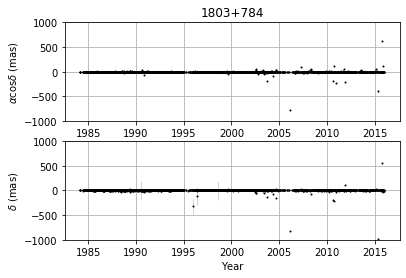

In [5]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(df_sel['BY'], df_sel['RAcosDEC']/1000,yerr=df_sel['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_sel['BY'], df_sel['Dec. (mas)'], yerr=df_sel['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

In [6]:
df_sel_ra = allanself.remove_outliers(df_sel,'RA')
df_sel_dec= allanself.remove_outliers(df_sel,'DEC')

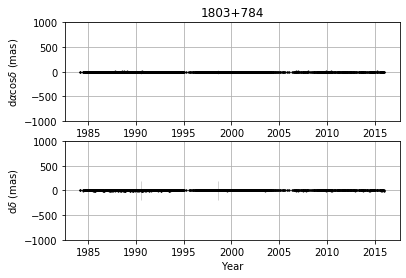

In [7]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(df_sel_ra['BY'], df_sel_ra['RAcosDEC']/1000,yerr=df_sel_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_sel_dec['BY'], df_sel_dec['Dec. (micas)']/1000, yerr=df_sel_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-1000,1000)
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()

In [8]:
radec_std = np.sqrt(allanself.wvar(df_sel_ra['RAcosDEC'].values/1000,1/(df_sel_ra['Err. R.A. (micas)'].values/1000)**2))
radec_std

0.5502300771300224

In [9]:
dec_std = np.sqrt(allanself.wvar(df_sel_dec['Dec. (micas)'].values/1000,1/(df_sel_dec['Err. Dec. (micas)'].values/1000)**2))
dec_std

0.6972948950400852

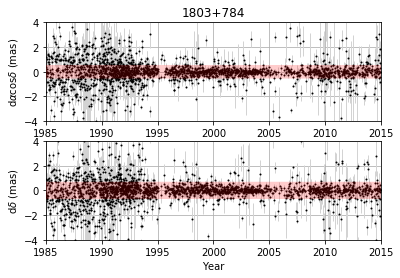

In [30]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(df_sel_ra['BY'], df_sel_ra['RAcosDEC']/1000,yerr=df_sel_ra['Err. R.A. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.fill_between(df_sel_ra['BY'], (-radec_std), (radec_std), facecolor='red', alpha=0.2, zorder=100)
plt.ylim(-4,4)
plt.xlim(1985,2015)
plt.xlabel('Year')
plt.ylabel(r'd$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df_sel_dec['BY'], df_sel_dec['Dec. (micas)']/1000, yerr=df_sel_dec['Err. Dec. (micas)']/1000, fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.fill_between(df_sel_dec['BY'], (-dec_std), (dec_std), facecolor='red', alpha=0.2, zorder=100)
plt.ylim(-4,4)
plt.xlim(1985,2015)
plt.xlabel('Year')
plt.ylabel('d$\delta$ (mas)')
plt.grid()
plt.show()

# Overlapping Allan

In [11]:
# %%time
# tau_dec, allanstd_dec = allanself.allanoadev(df_sel_dec['Dec. (micas)'].values,df_sel_dec['MJD'].values,df_sel_dec['Err. Dec. (micas)'].values)

# np.savetxt('1803+784_tau_dec.txt',tau_dec)
# np.savetxt('1803+784_allanstd_dec.txt',allanstd_dec)

In [31]:
# %%time
# tau_ra, allanstd_ra = allanself.allanoadev(df_sel_ra['RAcosDEC'].values,df_sel_ra['MJD'].values,df_sel_ra['Err. R.A. (micas)'].values)

CPU times: user 4min 48s, sys: 12.7 ms, total: 4min 48s
Wall time: 4min 48s


In [32]:
# np.savetxt('1803+784_tau_ra.txt',tau_ra)
# np.savetxt('1803+784_allanstd_ra.txt',allanstd_ra)

In [12]:
tau_dec = np.loadtxt('1803+784_tau_dec.txt')
allanstd_dec = np.loadtxt('1803+784_allanstd_dec.txt')

In [33]:
tau_ra = np.loadtxt('1803+784_tau_ra.txt')
allanstd_ra = np.loadtxt('1803+784_allanstd_ra.txt')

In [17]:
# confidence_int(y,error,dev,modified,overlapping,devtype):
ci_dec_low, ci_dec_high = allanself.confidence_int(df_sel_dec['Dec. (micas)'].values,df_sel_dec['Err. Dec. (micas)'].values,allanstd_dec,modified=False,overlapping=True,devtype='allan')

In [34]:
ci_ra_low, ci_ra_high = allanself.confidence_int(df_sel_ra['RAcosDEC'].values,df_sel_ra['Err. R.A. (micas)'].values,allanstd_ra,modified=False,overlapping=True,devtype='allan')

# Plot OADEV with Confidence Interval

In [35]:
tau_dec_year = [x/365.242198781 for x in tau_dec]
tau_ra_year = [x/365.242198781 for x in tau_ra]

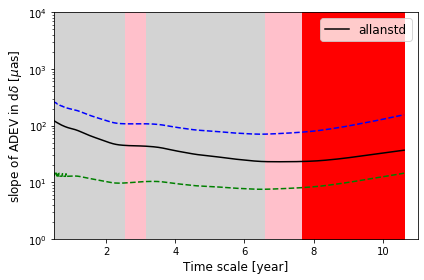

In [38]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec)) / np.diff(np.log10(tau_dec))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_year, allanstd_dec - ci_dec_low,color='green',linestyle='dashed')
# plt.plot(tau_dec_year, allanstd_mas + top_dec,color='yellow',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec + ci_dec_high,color='blue',linestyle='dashed')
# plt.plot(tau_dec_year, allanstd_dec + scipy.stats.chi2.ppf(0.1/2,edfs_dec),color='yellow',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in d$\delta$ [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

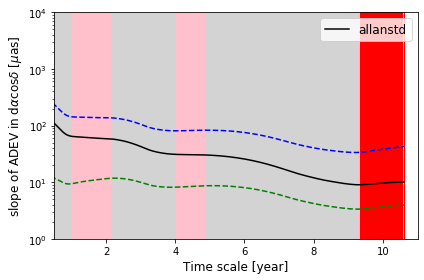

In [39]:
plt.figure()
# Calculate the slopes
slopes_ra = np.diff(np.log10(allanstd_ra)) / np.diff(np.log10(tau_ra))
# Plot allanstd
plt.plot(tau_ra_year,allanstd_ra,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= slopes_ra  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= (-0.25 <= slopes_ra ) & (slopes_ra  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_ra_year[1:], 1, 10**4, where= slopes_ra  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_ra_year, allanstd_ra - ci_ra_low,color='green',linestyle='dashed')
plt.plot(tau_ra_year, allanstd_ra + ci_ra_high,color='blue',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in d$\alpha \cos \delta$ [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

# Overlapping Hadamard

In [72]:
def hadoadev(y,t,error):
        
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Initial sampling time
    tau0 =  np.mean(np.diff(t))
    # Steps
    step = tau0
    
    # Empty variance array
    hadvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = min(t)
        right = min(t) + m[k]*tau0

        # Array for averages
        ybar = []

        # Array for amount of data points
        Nrray = []

        # Define no of windows with <= 2 data points
        nconstraint = 2
                
        # Check for missing windows 
        while right <= max(t):
            data_values = y[(t>=left) & (t<=right)]
            Ndata = len(data_values)
            Nrray.append(Ndata)

            if Ndata == 0:
                ybar.append(np.nan)
            else:
                if error is None: 
                    avg = np.average(data_values)
                    ybar.append(avg)
                else:
                    weights_std = 1/error[(t>=left) & (t<=right)]**2
                    avg = np.average(data_values, weights=weights_std)
                    ybar.append(avg)
            left += step 
            right += step    

        # Define empty windows 
        Nrray = np.array(Nrray)
        ybar = np.array(ybar)
        
        D = len(ybar[Nrray<=nconstraint])
        M = len(ybar)
        
        # Discard windows with too few data points
        ybar = ybar[Nrray>nconstraint]

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M-3*m[k]+1-D:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+2*m[k]]-2*ybar[i+m[k]]+ybar[i])
                i += 1
            outersum.append((np.sum(innersum)/m[k])**2)
            j += 1
            
        # Calculate allan variance
        hadvar.append(np.sum(outersum)/(6*(M-3*m[k]+1-D)))
        
        # Calculate tau
        tau.append(tau0*m[k])
                
    # Calculate allan std dev
    hadstd = np.sqrt(hadvar)
        
    return tau, hadstd

In [73]:
%%time
tau_dec_had, hadstd_dec = hadoadev(df_sel_dec['Dec. (micas)'].values,df_sel_dec['MJD'].values,df_sel_dec['Err. Dec. (micas)'].values)


KeyboardInterrupt: 

In [46]:
# %%time
# tau_ra_had, hadstd_ra = hadoadev(df_sel_ra['RAcosDEC'].values,df_sel_ra['MJD'].values,df_sel_ra['Err. R.A. (micas)'].values)

CPU times: user 4min 32s, sys: 3.91 ms, total: 4min 32s
Wall time: 4min 32s


In [47]:
# np.savetxt('1803+784_tau_dec_had.txt',tau_dec_had)
# np.savetxt('1803+784_hadstd_dec.txt',hadstd_dec)

# np.savetxt('1803+784_tau_ra_had.txt',tau_ra_had)
# np.savetxt('1803+784_hadstd_ra.txt',hadstd_ra)

In [48]:
tau_dec_had = np.loadtxt('1803+784_tau_dec_had.txt')
hadstd_dec = np.loadtxt('1803+784_allanstd_dec.txt')

tau_ra_had = np.loadtxt('1803+784_tau_ra_had.txt')
hadstd_ra = np.loadtxt('1803+784_hadstd_ra.txt')

In [50]:
# confidence_int(y,error,dev,modified,overlapping,devtype):
ci_dec_had_low, ci_dec_had_high = allanself.confidence_int(df_sel_dec['Dec. (micas)'].values,df_sel_dec['Err. Dec. (micas)'].values,hadstd_dec,modified=False,overlapping=True,devtype='hadamard')

In [51]:
ci_ra_had_low, ci_ra_had_high = allanself.confidence_int(df_sel_ra['RAcosDEC'].values,df_sel_ra['Err. R.A. (micas)'].values,hadstd_ra,modified=False,overlapping=True,devtype='hadamard')

# Plot OHDEV with CI

In [52]:
tau_dec_had_year = [x/365.242198781 for x in tau_dec_had]
tau_ra_had_year = [x/365.242198781 for x in tau_ra_had]

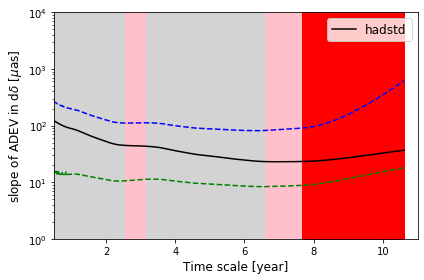

In [53]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(hadstd_dec)) / np.diff(np.log10(tau_dec_had))
# Plot allanstd
plt.plot(tau_dec_had_year,hadstd_dec,color='black',label='hadstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_had_year[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_had_year[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_dec_had_year[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_had_year, hadstd_dec - ci_dec_had_low,color='green',linestyle='dashed')
plt.plot(tau_dec_had_year, hadstd_dec + ci_dec_had_high,color='blue',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in d$\delta$ [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

/home/anto/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until


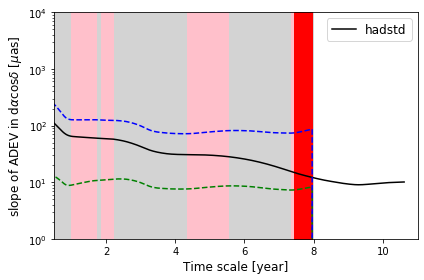

In [55]:
plt.figure()
# Calculate the slopes
slopes_ra = np.diff(np.log10(hadstd_ra)) / np.diff(np.log10(tau_ra_had))
# Plot allanstd
plt.plot(tau_ra_had_year,allanstd_ra,color='black',label='hadstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_ra_had_year[1:], 1, 10**4, where= slopes_ra  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_ra_had_year[1:], 1, 10**4, where= (-0.25 <= slopes_ra ) & (slopes_ra  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_ra_had_year[1:], 1, 10**4, where= slopes_ra  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_ra_had_year, hadstd_ra - ci_ra_had_low,color='green',linestyle='dashed')
plt.plot(tau_ra_had_year, hadstd_ra + ci_ra_had_high,color='blue',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in d$\alpha \cos \delta$ [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

In [62]:
np.count_nonzero(hadstd_ra)

540

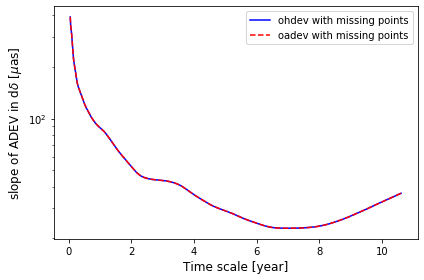

In [102]:
plt.figure()
plt.plot(tau_dec_had_year,hadstd_dec,color='blue',label='ohdev with missing points')
plt.plot(tau_dec_year,allanstd_dec,color='red',label='oadev with missing points',linestyle='dashed')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in d$\delta$ [$\mu$as]', fontsize=12)
plt.yscale('log')
plt.legend()
plt.tight_layout()

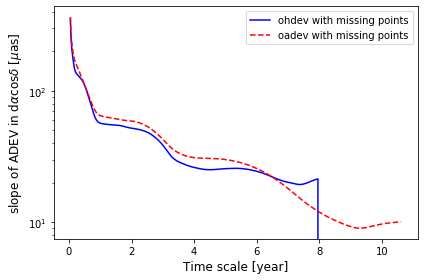

In [103]:
plt.figure()
plt.plot(tau_ra_had_year,hadstd_ra,color='blue',label='ohdev with missing points')
plt.plot(tau_ra_year,allanstd_ra,color='red',label='oadev with missing points',linestyle='dashed')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in d$\alpha \cos \delta$ [$\mu$as]', fontsize=12)
plt.yscale('log')
plt.legend()
plt.tight_layout()

In [87]:
def ohdev(y):
    M = len(y)
    m = np.arange(3,M//3+1,1)
    havar = []
    for k in range(len(m)):
        outersum = []
        j = 0
        while j < M-3*m[k]+1:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(y[i+2*m[k]]-2*y[i+m[k]]+y[i])
                i += 1
            outersum.append((np.sum(innersum)/m[k])**2)
            j += 1
    
        # Calculate allan variance
        havar.append(np.sum(outersum)/(6*(M-3*m[k]+1)))

    return np.sqrt(havar)
    

In [89]:
ohdev_dec = ohdev(df_sel_dec['Dec. (micas)'].values)

<function matplotlib.pyplot.show(*args, **kw)>

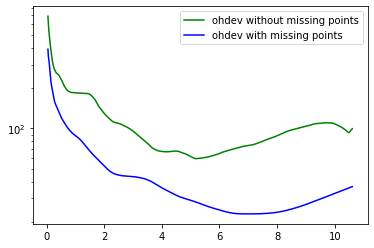

In [97]:
plt.plot(tau_dec_had_year, ohdev_dec,color='green', label='ohdev without missing points')
plt.plot(tau_dec_had_year,hadstd_dec,color='blue',label='ohdev with missing points')
plt.yscale('log')
plt.legend()
plt.show